In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files
uploaded= files.upload()

Saving member_features.parquet to member_features.parquet


In [4]:
df = pd.read_parquet("member_features.parquet")

In [5]:
df.sample(3)

,member_id,num_chronic_conditions,diabetes_flag,chf_flag,copd_flag,renal_flag,behavioral_health_flag,prior_er_visits_90d,pcp_touch_90d,risk_bin,has_avoidable_er
37038,M37038,1,0,1,0,0,1,1.0,3.0,Medium,1
20390,M20390,0,0,0,0,0,0,0.0,1.0,Medium,0
45615,M45615,0,0,0,0,0,0,1.0,0.0,Low,0


In [6]:
X= df.drop(columns=["member_id","has_avoidable_er"])

In [7]:
Y= df["has_avoidable_er"]

In [8]:
X.sample(3)

,num_chronic_conditions,diabetes_flag,chf_flag,copd_flag,renal_flag,behavioral_health_flag,prior_er_visits_90d,pcp_touch_90d,risk_bin
41123,0,0,0,0,0,0,0.0,0.0,Low
40360,0,0,0,0,0,0,1.0,1.0,Low
46141,0,0,0,0,0,0,0.0,1.0,Low


In [9]:
Y.sample(3)

,has_avoidable_er
549,0
22032,0
47540,1


In [10]:
X["risk_bin"] = X["risk_bin"].map({"Low":0, "Medium": 1, "High": 2})


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,Y, test_size=0.2, random_state= 42, stratify = Y
)

In [13]:
!pip install lightgbm

In [14]:
from lightgbm import LGBMClassifier

In [15]:
model = LGBMClassifier(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth=5,
    random_state=42
)

In [16]:
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 10174, number of negative: 29826
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018046 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.254350 -> initscore=-1.075545
[LightGBM] [Info] Start training from score -1.075545
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

LGBMClassifier(learning_rate=0.05, max_depth=5, n_estimators=300,
               random_state=42)

In [17]:
from sklearn.metrics import roc_auc_score

In [18]:
y_pred_proba = model.predict_proba(X_test)[:,1]

In [19]:
auc = roc_auc_score(y_test, y_pred_proba)

In [20]:
print(auc)

0.6831991920735822


In [21]:
pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending= False)

,0
pcp_touch_90d,1591
prior_er_visits_90d,1364
num_chronic_conditions,912
behavioral_health_flag,632
risk_bin,463
renal_flag,460
diabetes_flag,411
copd_flag,355
chf_flag,338


In [22]:
!pip install shap

In [23]:
import shap

In [24]:
explainer = shap.TreeExplainer(model)

In [25]:
shap_values = explainer.shap_values (X_test)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


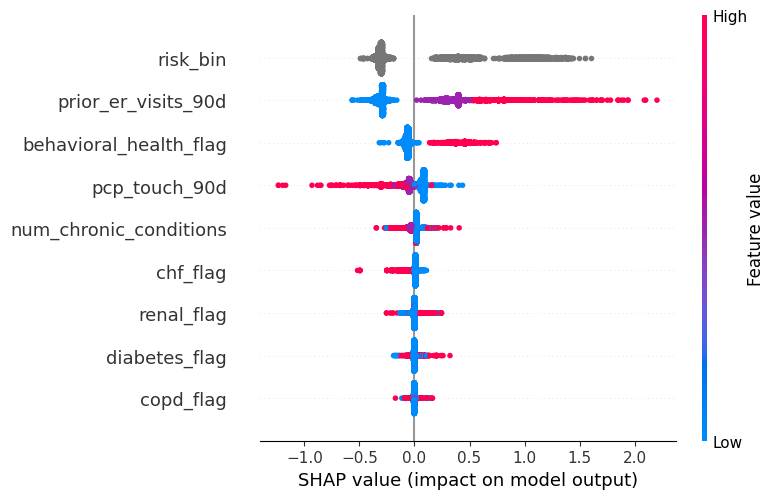

In [26]:
shap.summary_plot(shap_values, X_test)

In [27]:
from sklearn.calibration import calibration_curve

In [28]:
import matplotlib.pyplot as plt

In [29]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

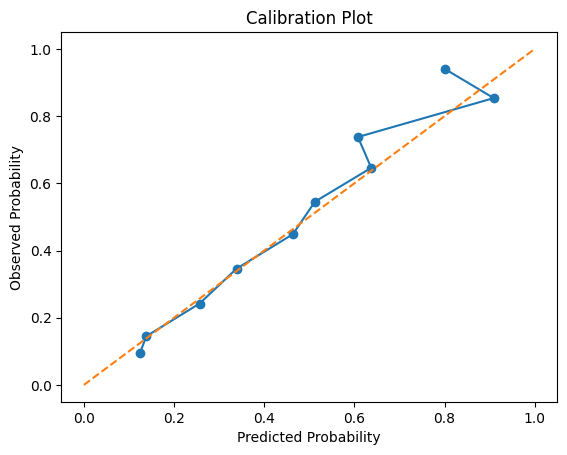

In [30]:
plt.plot(prob_true, prob_pred, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Calibration Plot")
plt.show()

In [31]:
import joblib

In [32]:
joblib.dump(model,"lgbm_avoidable_er_model.pkl")

['lgbm_avoidable_er_model.pkl']

In [33]:
test_output = X_test.copy()
test_output["actual"] = y_test.values
test_output["predicted_proba"] = y_pred_proba

test_output.to_parquet("phase3_test_predictions.parquet", index=False)


In [34]:
import numpy as np

np.save("phase3_shap_values.npy", shap_values)
X_test.to_parquet("phase3_shap_input.parquet", index=False)


In [35]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.to_csv("phase3_feature_importance.csv")

In [36]:
import os
print(os.getcwd())


/content


In [37]:
os.listdir()

['.config',
 'phase3_shap_input.parquet',
 'member_features.parquet',
 'lgbm_avoidable_er_model.pkl',
 'drive',
 'phase3_feature_importance.csv',
 'phase3_test_predictions.parquet',
 'phase3_shap_values.npy',
 'sample_data']

In [38]:
from google.colab import files

files.download("lgbm_avoidable_er_model.pkl")
files.download("phase3_test_predictions.parquet")
files.download("phase3_shap_values.npy")
files.download("phase3_shap_input.parquet")
files.download("phase3_feature_importance.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
joblib.dump(model, "/content/drive/MyDrive/lgbm_avoidable_er_model.pkl")

['/content/drive/MyDrive/lgbm_avoidable_er_model.pkl']